In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import contextily as ctx
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely import wkt

In [9]:
!pip install folium


In [10]:
!pip install contextily

In [11]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1iIuP-HFFJVjKmsQZnxFrSE68JF-vdRBL')
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-12-04T02:33:58.960Z,19.323166,-155.245331,-0.02,2.02,ml,53.0,78.0,0.046060,0.26,...,2025-12-04T02:37:58.140Z,"13 km S of Volcano, Hawaii",earthquake,0.20,0.20,0.330000,21.0,automatic,hv,hv
1,2025-12-04T02:32:58.430Z,36.058833,-117.443333,4.32,1.01,ml,19.0,90.0,0.037020,0.17,...,2025-12-04T02:36:36.973Z,"33 km N of Searles Valley, CA",earthquake,0.28,0.36,0.105022,11.0,automatic,ci,ci
2,2025-12-04T02:29:17.390Z,36.139000,-118.440333,7.22,0.81,ml,23.0,84.0,0.103700,0.16,...,2025-12-04T02:32:58.298Z,"42 km WSW of Olancha, CA",earthquake,0.23,0.73,0.136793,9.0,automatic,ci,ci
3,2025-12-04T02:28:38.170Z,38.805500,-122.777496,3.25,0.72,md,12.0,70.0,0.008138,0.01,...,2025-12-04T02:30:15.366Z,"4 km NNW of The Geysers, CA",earthquake,0.43,1.00,0.050000,12.0,automatic,nc,nc
4,2025-12-04T02:25:38.220Z,38.778999,-122.757668,1.09,1.03,md,13.0,62.0,0.010400,0.03,...,2025-12-04T02:27:15.431Z,"0 km NNW of The Geysers, CA",earthquake,0.27,0.49,0.210000,11.0,automatic,nc,nc


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8627 entries, 0 to 8626
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             8627 non-null   object 
 1   latitude         8627 non-null   float64
 2   longitude        8627 non-null   float64
 3   depth            8627 non-null   float64
 4   mag              8627 non-null   float64
 5   magType          8627 non-null   object 
 6   nst              8034 non-null   float64
 7   gap              8032 non-null   float64
 8   dmin             8032 non-null   float64
 9   rms              8627 non-null   float64
 10  net              8627 non-null   object 
 11  id               8627 non-null   object 
 12  updated          8627 non-null   object 
 13  place            8627 non-null   object 
 14  type             8627 non-null   object 
 15  horizontalError  7772 non-null   float64
 16  depthError       8571 non-null   float64
 17  magError      

# DATA CLEANING

In [13]:
df.isnull().sum()

,0
time,0
latitude,0
longitude,0
depth,0
mag,0
magType,0
nst,593
gap,595
dmin,595
rms,0


In [94]:
df_cleaned = df.dropna().copy()
display(df_cleaned.isnull().sum())

,0
time,0
latitude,0
longitude,0
depth,0
mag,0
magType,0
nst,0
gap,0
dmin,0
rms,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [19]:
# Buat peta dasar Amerika Serikat (AS)
peta_us = folium.Map(location=[39.8, -98.5], zoom_start=3)

# Buat list data [latitude, longitude, mag] untuk heatmap
data_heatmap = df[['latitude', 'longitude', 'mag']].values.tolist()

# Tambahkan heatmap ke peta
HeatMap(data_heatmap, radius=12, blur=15, max_zoom=6).add_to(peta_us)

# Tampilkan peta
peta_us

In [41]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

# Jitter koordinat agar tidak tumpang tindih
np.random.seed(42)
long_peta = df['longitude'] + np.random.uniform(-0.05, 0.05, size=len(df))
lat_peta = df['latitude'] + np.random.uniform(-0.05, 0.05, size=len(df))

# Konversi ke GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(long_peta, lat_peta),
    crs='EPSG:4326'
)

# Proyeksi ke Web Mercator
gdf = gdf.to_crs(epsg=3857)

# Menghitung jumlah peristiwa gempa (count) untuk setiap lokasi ('place')
jumlah_gempa_per_lokasi = df.groupby("place").size().rename("Jumlah Gempa")
top_5_count = jumlah_gempa_per_lokasi.sort_values(ascending=False).head(5)
bottom_5_count = jumlah_gempa_per_lokasi.sort_values().head(5)



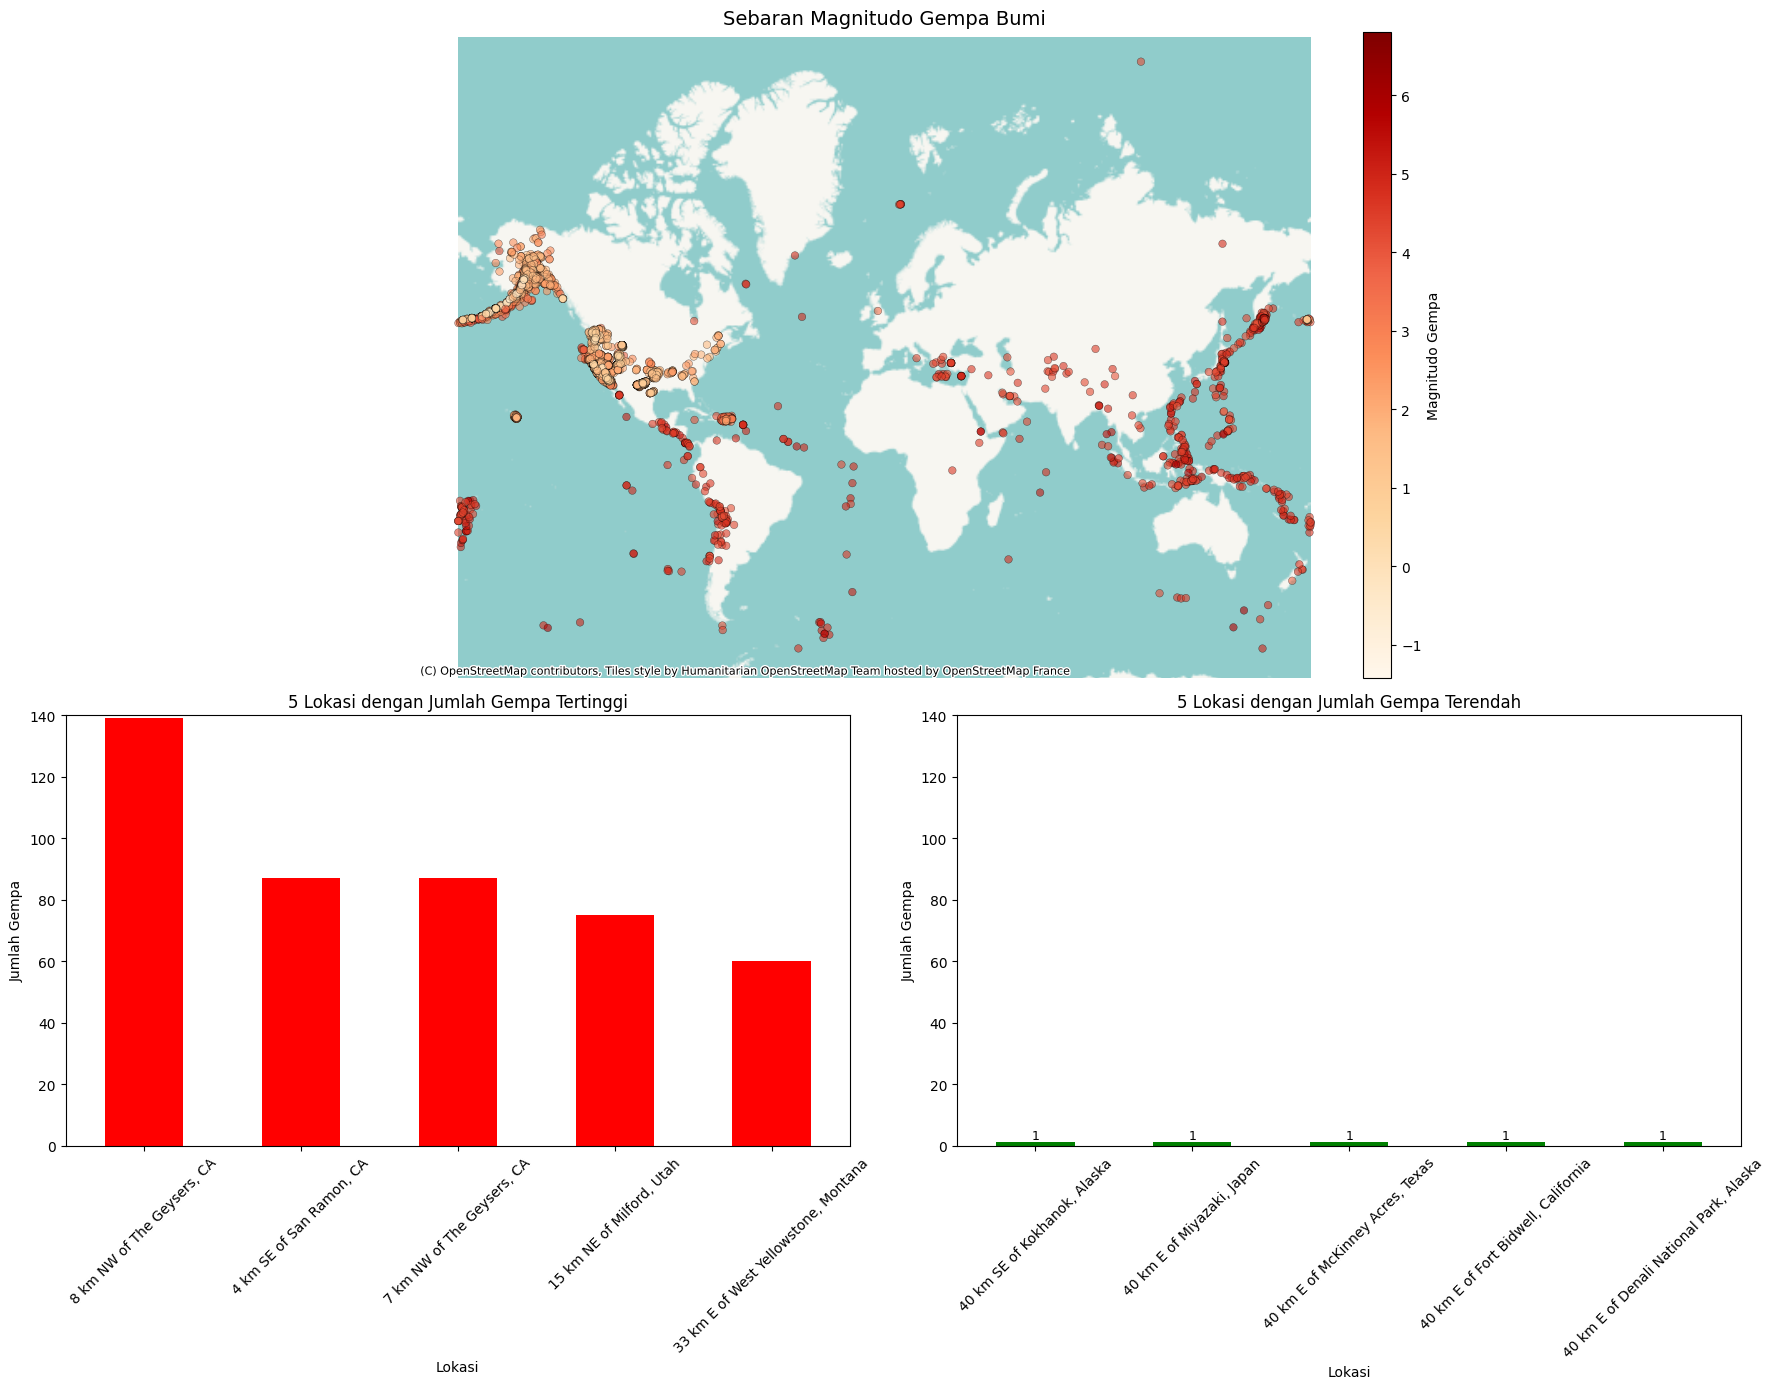

In [74]:
# Buat layout dengan GridSpec
gs = gridspec.GridSpec(2, 2, figure=plt.figure(figsize=(18, 14)), height_ratios=[3, 2])

# --- Row 1: Peta sebaran (colspan=2) ---
ax_map = plt.subplot(gs[0, :])
divider = make_axes_locatable(ax_map)
cax = divider.append_axes("right", size="3%", pad=0.1)

gdf.plot(
    ax=ax_map,
    column='mag',
    cmap='OrRd',
    legend=True,
    legend_kwds={'label': "Magnitudo Gempa", 'orientation': "vertical"},
    cax=cax,
    markersize=30,
    edgecolor='black',
    linewidth=0.3,
    alpha=0.6
)

ctx.add_basemap(ax_map)
ax_map.set_title("Sebaran Magnitudo Gempa Bumi", fontsize=14)
ax_map.axis('off')


ax_top = plt.subplot(gs[1, 0])
bars_top = top_5_count.plot(kind='bar', ax=ax_top, color='red')
ax_top.set_title("5 Lokasi dengan Jumlah Gempa Tertinggi")
ax_top.set_ylabel("Jumlah Gempa")
ax_top.set_xlabel("Lokasi")
ax_top.tick_params(axis='x', rotation=45)

ax_bottom = plt.subplot(gs[1, 1])
bars_bottom = bottom_5_count.plot(kind='bar', ax=ax_bottom, color='green')
ax_bottom.set_title("5 Lokasi dengan Jumlah Gempa Terendah")
ax_bottom.set_ylabel("Jumlah Gempa")
ax_bottom.set_xlabel("Lokasi")
ax_bottom.tick_params(axis='x', rotation=45)

# Tambahkan anotasi
for i, val in enumerate(bottom_5_count):
    ax_bottom.text(i, val + 0.2, f'{val:.0f}', ha='center', va='bottom', fontsize=9)

# Sinkronisasi skala Y kedua chart
max_val = max(top_5_count.max(), bottom_5_count.max()) # Corrected from top_5 and bottom_5
ax_top.set_ylim(0, max_val + 1)
ax_bottom.set_ylim(0, max_val + 1)

plt.tight_layout()
plt.show()

In [45]:
df.columns

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource'],
      dtype='object')

# UJI NORMALITAS

HAPUS KOLOM NON NUMERIK

In [47]:
from scipy.stats import shapiro

normalityTest_df = df.drop(columns=['time', 'magType', 'net', 'id', 'updated', 'place', 'type', 'status', 'locationSource', 'magSource'])
normalityTest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8627 entries, 0 to 8626
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   latitude         8627 non-null   float64
 1   longitude        8627 non-null   float64
 2   depth            8627 non-null   float64
 3   mag              8627 non-null   float64
 4   nst              8034 non-null   float64
 5   gap              8032 non-null   float64
 6   dmin             8032 non-null   float64
 7   rms              8627 non-null   float64
 8   horizontalError  7772 non-null   float64
 9   depthError       8571 non-null   float64
 10  magError         7991 non-null   float64
 11  magNst           8034 non-null   float64
dtypes: float64(12)
memory usage: 808.9 KB


In [54]:
ata_to_test = df_cleaned['mag']

stat, p = shapiro(data_to_test)

print("Statik: ", stat)
print("P-value: ", p)

if p > 0.05:
    print("Data berdistribusi normal (tidak tolak H0)")
else:
    print("Data tidak berdistribusi normal (tolak H0)")

Statik:  0.904814870822158
P-value:  2.9055981215915856e-56
Data tidak berdistribusi normal (tolak H0)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7671.
  res = hypotest_fun_out(*samples, **kwds)


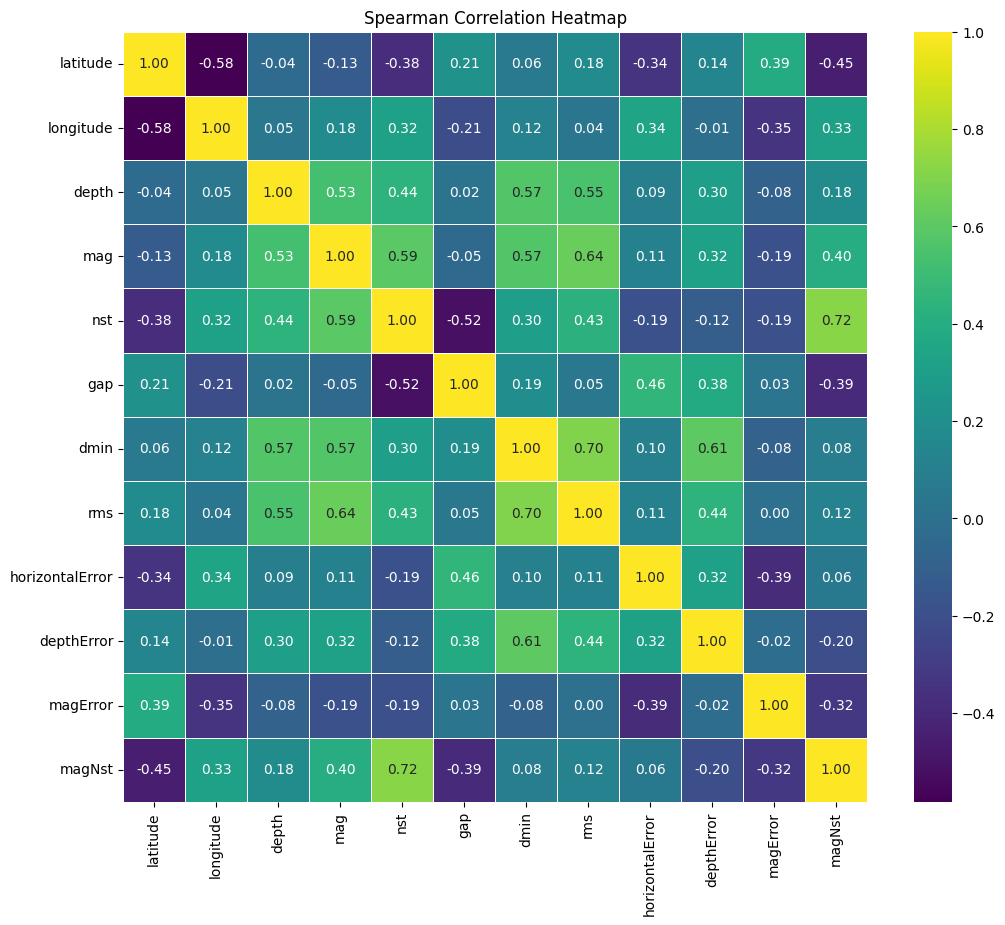

In [55]:
correlation_df = normalityTest_df

correlation_matrix = correlation_df.corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation Heatmap")
plt.show()

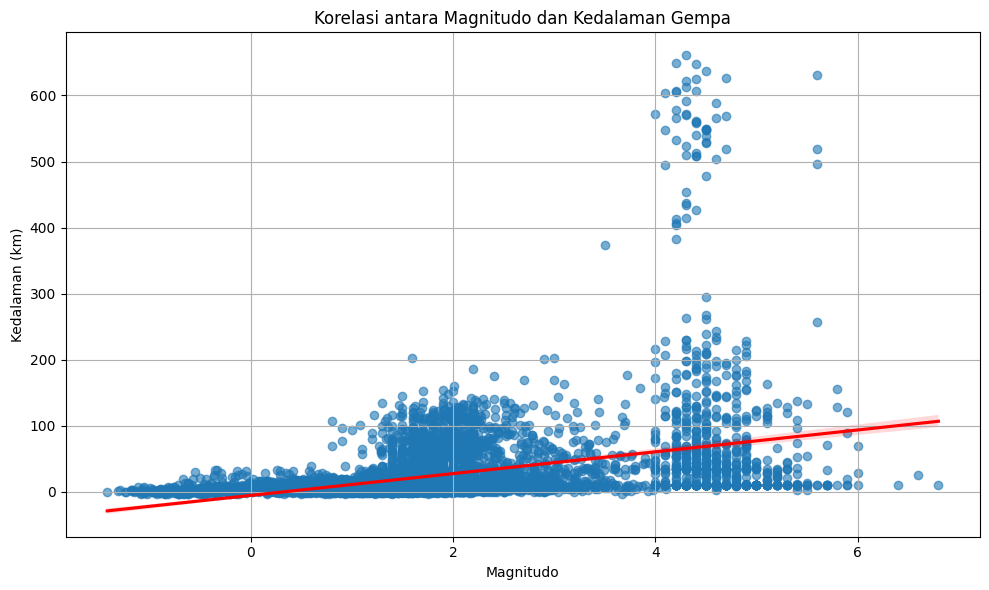

In [57]:
plt.figure(figsize=(10, 6))
sns.regplot(
    x="mag",
    y="depth",
    data=df,
    scatter_kws={'alpha':0.6},
    line_kws={"color": "red"}
)
plt.title("Korelasi antara Magnitudo dan Kedalaman Gempa")
plt.xlabel("Magnitudo")
plt.ylabel("Kedalaman (km)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [61]:
# Gunakan df_cleaned yang sudah bebas NaN
normalisasi_df = df_cleaned.drop(columns=['time', 'magType', 'net', 'id', 'updated', 'place', 'type', 'status', 'locationSource', 'magSource'])
normalisasi_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7671 entries, 0 to 8625
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   latitude         7671 non-null   float64
 1   longitude        7671 non-null   float64
 2   depth            7671 non-null   float64
 3   mag              7671 non-null   float64
 4   nst              7671 non-null   float64
 5   gap              7671 non-null   float64
 6   dmin             7671 non-null   float64
 7   rms              7671 non-null   float64
 8   horizontalError  7671 non-null   float64
 9   depthError       7671 non-null   float64
 10  magError         7671 non-null   float64
 11  magNst           7671 non-null   float64
dtypes: float64(12)
memory usage: 779.1 KB


In [59]:
from sklearn.preprocessing import RobustScaler

column_names = normalisasi_df.columns
scaler = RobustScaler()
normalisasi_df = scaler.fit_transform(normalisasi_df)
normalisasi_df = pd.DataFrame(normalisasi_df, columns=column_names)
normalisasi_df.head()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
0,-0.925974,-0.865077,-0.597349,0.512605,1.375000,-0.128571,-0.048781,0.257143,-0.282901,-0.408163,1.157918,0.714286
1,-0.130886,0.132857,-0.243174,-0.336134,-0.041667,0.042857,-0.104355,0.000000,-0.132020,-0.299320,-0.533645,0.000000
2,-0.127078,0.106538,-0.006512,-0.504202,0.125000,-0.042857,0.305566,-0.028571,-0.226321,-0.047619,-0.294764,-0.142857
3,-0.000396,-0.007959,-0.330493,-0.579832,-0.333333,-0.242857,-0.281910,-0.457143,0.150880,0.136054,-0.947345,0.071429
4,-0.001655,-0.007436,-0.506765,-0.319328,-0.291667,-0.357143,-0.268005,-0.400000,-0.150880,-0.210884,0.255663,0.000000


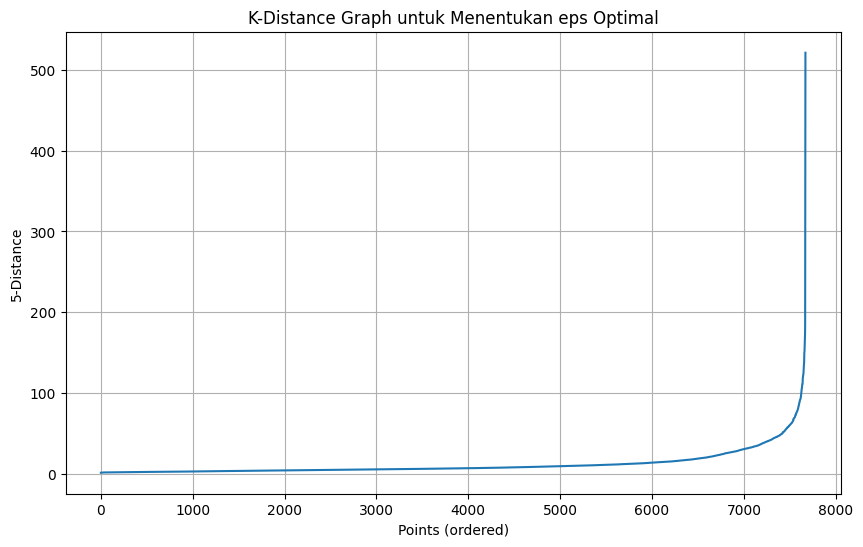

In [62]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Gunakan data hasil normalisasi
X = normalisasi_df.values

# Tentukan jumlah tetangga (min_samples biasanya = 4-10)
k = 5

# Fit nearest neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Ambil jarak tetangga ke-k (k-distance)
k_distances = np.sort(distances[:, k-1])

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title("K-Distance Graph untuk Menentukan eps Optimal")
plt.ylabel(f"{k}-Distance")
plt.xlabel("Points (ordered)")
plt.grid(True)
plt.show()

In [89]:
from sklearn.cluster import DBSCAN

# Increased eps to reduce the number of clusters
dbscan = DBSCAN(eps=5.0, min_samples=5)
labels = dbscan.fit_predict(normalisasi_df.values)

# Assign labels to df_cleaned, which has the correct number of rows
# and corresponds to the data used for clustering.
df_cleaned["Cluster_DBSCAN"] = labels
print(df_cleaned["Cluster_DBSCAN"].value_counts())

Cluster_DBSCAN
-1     4206
 0     1635
 2      560
 9      219
 1      168
       ... 
 60       5
 31       3
 6        3
 48       3
 55       2
Name: count, Length: 62, dtype: int64


/tmp/ipython-input-877614101.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Cluster_DBSCAN"] = labels


In [90]:
from sklearn.metrics import silhouette_score

# 'labels' are already generated from the DBSCAN in cell cfhzZ4YwQRhI
# Ensure normalisasi_df and labels have consistent indices/order
# Use df_cleaned for masking to align with the labels assigned there

mask = df_cleaned["Cluster_DBSCAN"] != -1 # Filter out noise points

# Ensure that there are enough clusters and samples to compute silhouette score
# We filter normalisasi_df based on the mask created from df_cleaned's 'Cluster_DBSCAN'
if len(set(df_cleaned["Cluster_DBSCAN"][mask])) > 1 and len(normalisasi_df[mask]) > 1:
    score = silhouette_score(normalisasi_df[mask], df_cleaned["Cluster_DBSCAN"][mask])
    print("Silhouette Score:", score)
else:
    print("Not enough clusters (or all noise) found to compute silhouette score with current parameters. Adjust eps or min_samples for DBSCAN.")

Silhouette Score: -0.2604622316175001


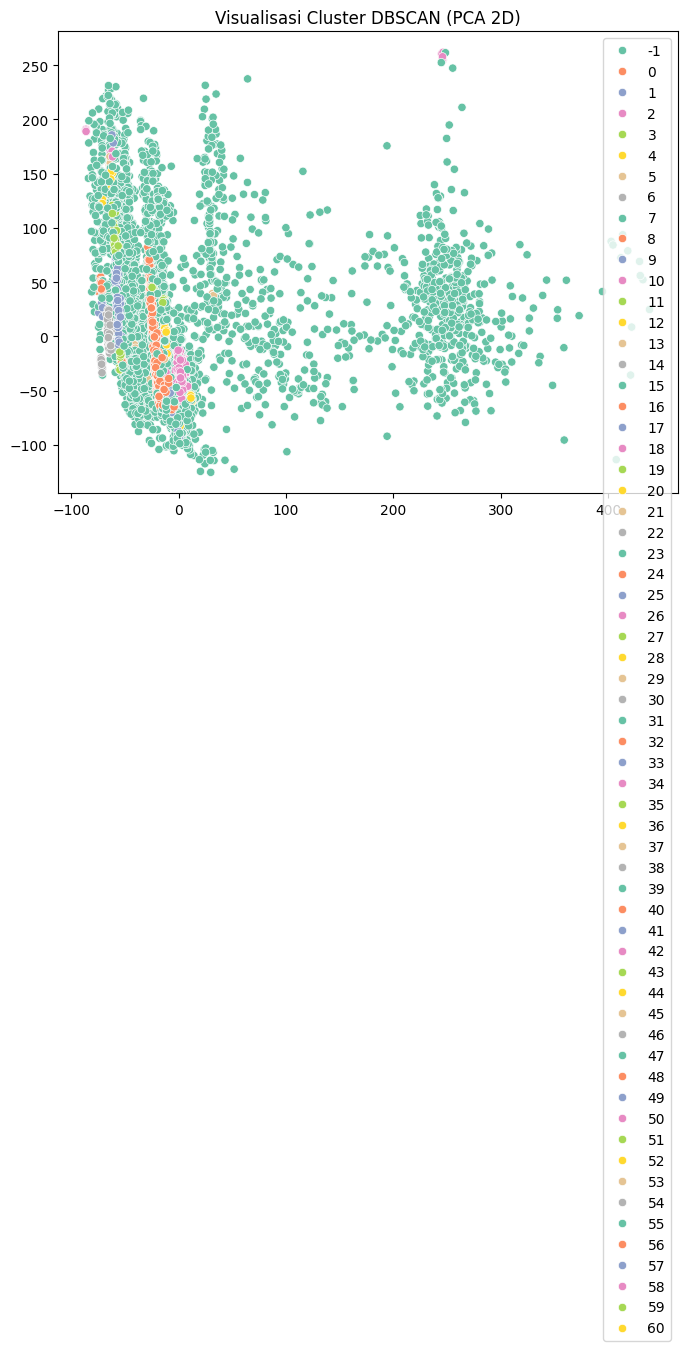

In [91]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(normalisasi_df)

plt.figure(figsize=(8,6))
sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=labels, palette="Set2")
plt.title("Visualisasi Cluster DBSCAN (PCA 2D)")
plt.show()

In [93]:
def klasifikasi_db(x):
    if x == 0:
        return "Baik"
    elif x == -1:
        return "Noise"
    else:
        return "Kurang"

df_cleaned['Klasifikasi_DBSCAN'] = df_cleaned['Cluster_DBSCAN'].apply(klasifikasi_db)

print(df_cleaned['Klasifikasi_DBSCAN'].value_counts())

Klasifikasi_DBSCAN
Noise     4206
Kurang    1830
Baik      1635
Name: count, dtype: int64


/tmp/ipython-input-3013371493.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Klasifikasi_DBSCAN'] = df_cleaned['Cluster_DBSCAN'].apply(klasifikasi_db)
